In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import random
# from random mport uniform

In [2]:
def f(x):
    return 3*x**2 - 4*x +5

In [3]:
f(3.0)

20.0

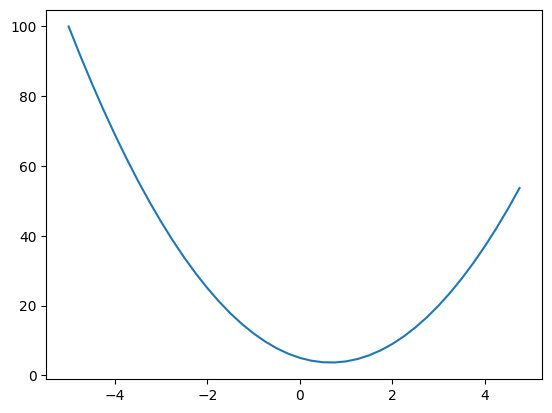

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs,ys)

In [5]:
h = 0.001
x =3.0
(f(x + h) - f(x))/ h



14.00300000000243

In [6]:
a= 2.0
b = -3.0
c= 10.0
d = a*b +c

print(d)


4.0


In [7]:
h = 0.0001
a = 2.0
b = -3.0
c = 10.0

d1 =a*b +c
a += h 
d2 = a*b +c

print('d1 ', d1)
print('d2 ', d2)
print('slope', (d2- d1)/ h)

d1  4.0
d2  3.999699999999999
slope -3.000000000010772


In [8]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data  = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        
        return out
    
    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data *out.grad
            other.grad += self.data * out.grad
        out._backward = _backward 
        
        return out
    
    def tanh(self):
        n = self.data
        t = (math.exp(2 *n) -1)/ (math.exp(2 *n) +1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 -t**2) *out.grad
        out._backward = _backward

        return out

    def __rmul__(self, other):
        return self* other

    def backward(self):
        topo = []
        visited =set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


In [9]:
from graphviz import Digraph

# builds set of nodes and edges in graph 
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name= uid, label = "{ %s | data %.4f | grad %.4f}"% (n.label ,n.data, n.grad), shape='record')
        
        if n._op:
            dot.node(name = uid +n._op, label=n._op)
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [10]:
a.data += 0.01 *a.grad
b.data += 0.01 *b.grad
c.data += 0.01 * c.grad
f.data += 0.01* f.grad

e= a * b
d = e + c
L = d*f

print(L.data)

AttributeError: 'float' object has no attribute 'data'

In [ ]:
# inputs 
x1 =Value(2.0, label='x1')
x2 =Value(0, label='x2')
# wieghts
w1 =Value(-3.0, label='w1')
w2 =Value(1.0, label='w2')  
b = Value(8, label='b')   # bias of neuron

# x1*w1 + x2*w2 + b
x1w1 =x1*w1; x1w1.label = 'x1w1'
x2w2 =x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n =x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()

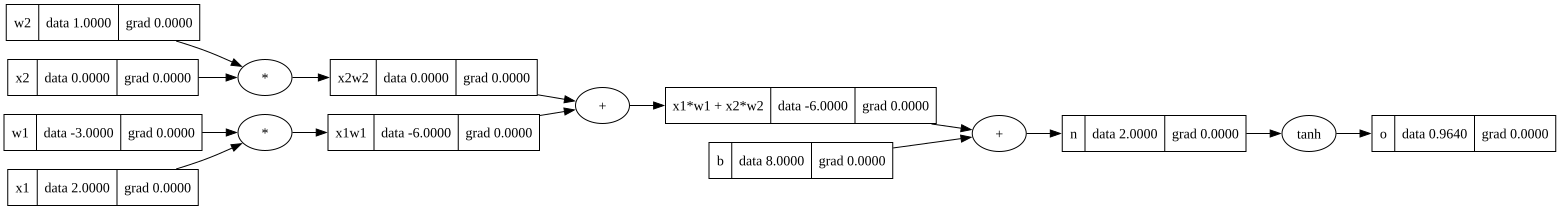

In [ ]:
draw_dot(o)

In [ ]:
# inputs 
x1 =Value(2.0, label='x1')
x2 =Value(0, label='x2')
# wieghts
w1 =Value(-3.0, label='w1')
w2 =Value(1.0, label='w2')  
b = Value(8, label='b')   # bias of neuron

# x1*w1 + x2*w2 + b
x1w1 =x1*w1; x1w1.label = 'x1w1'
x2w2 =x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n =x1w1x2w2 + b; n.label = 'n'

e= (n*2).exp()
o = (e -1)/(e +1)
o.label = 'o'
o.backward()
draw_dot(o)

AttributeError: 'Value' object has no attribute 'exp'

In [19]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # w*x +b
        act= sum(wi*xi for wi, xi in zip(self.w, x)) + self.b
        out = act.tanh()
        return out
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    def __call__(self, x):
        outs = [n(x) for n in self.neurons] 
        return outs

class MLP:
    def __init__(self,nin, nouts):
        sz =[nin] + nouts
        self.layers = [Layer(sz[i], sz[i +1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

x =[2.0, 3.0, -1.0]
n = MLP(3, [4,4,1])
n(x)


[Value(data=-0.9942490434975854)]

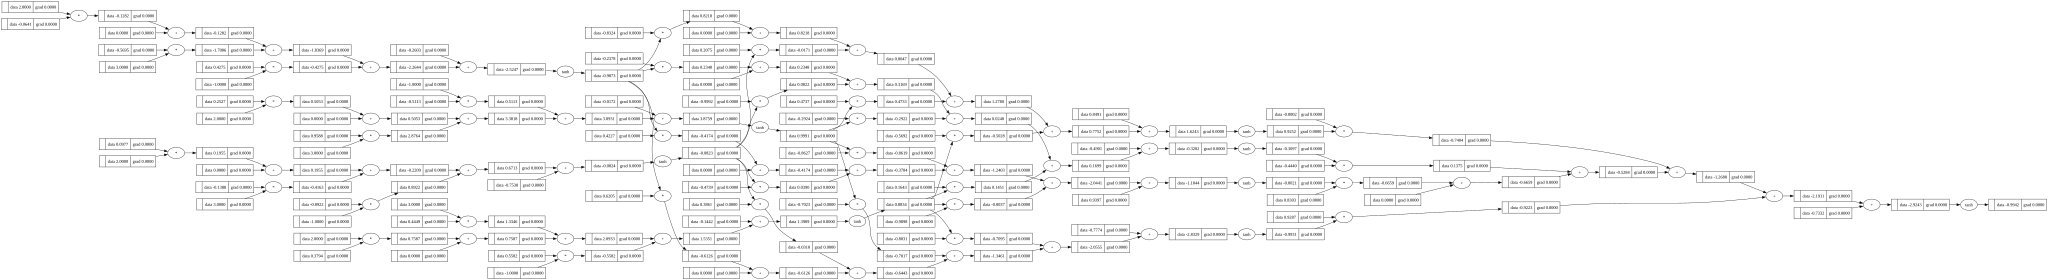

In [21]:
out = n(x)[0]
draw_dot(out)